# ImplexConv Dataset Preprocessing

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import os

# 한글 폰트 설정
plt.rcParams['font.family'] = 'DejaVu Sans'

data_dir = 'implexconv'
opposed_path = os.path.join(data_dir, 'ImplexConv_opposed.json')
supportive_path = os.path.join(data_dir, 'ImplexConv_supportive.json')

# 데이터 로드
with open(opposed_path, 'r') as f:
    data_opposed = json.load(f)

with open(supportive_path, 'r') as f:
    data_supportive = json.load(f)

print(f"Opposed sessions: {len(data_opposed)}")
print(f"Supportive sessions: {len(data_supportive)}")

Opposed sessions: 1550
Supportive sessions: 814


## 셀1: 데이터 분석


Analysis for ImplexConv_opposed

Total Sessions: 1550

Conversation counts per session:
  Mean: 110.43
  Min: 106
  Max: 137
  Std: 1.89

QA counts per session:
  Mean: 2.34
  Min: 0
  Max: 5
  Std: 1.27


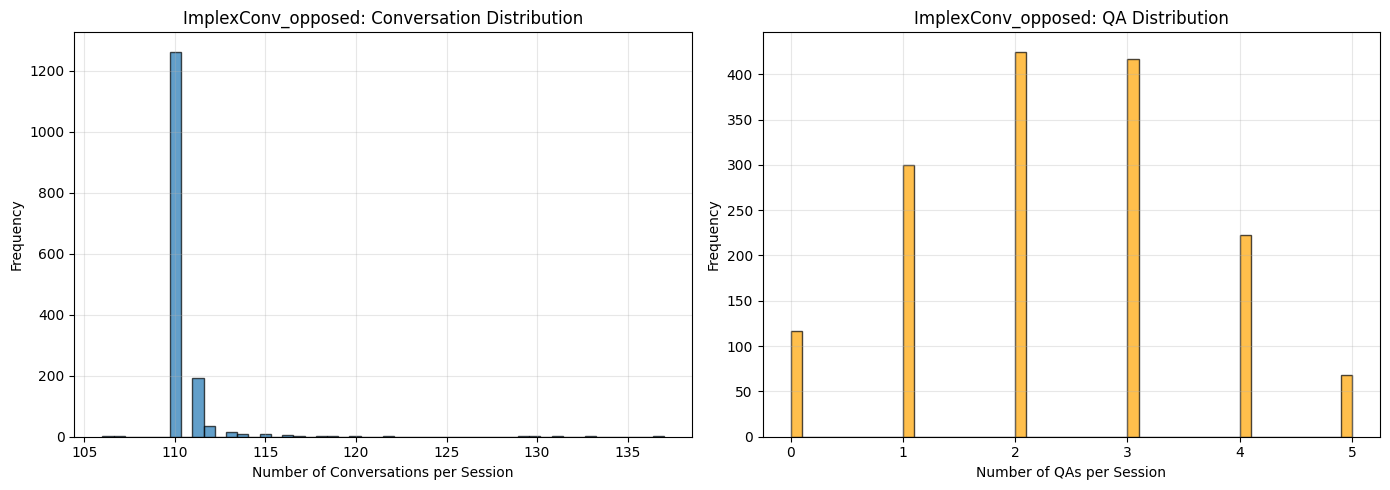


Analysis for ImplexConv_supportive

Total Sessions: 814

Conversation counts per session:
  Mean: 83.93
  Min: 63
  Max: 107
  Std: 7.58

QA counts per session:
  Mean: 6.00
  Min: 6
  Max: 6
  Std: 0.00


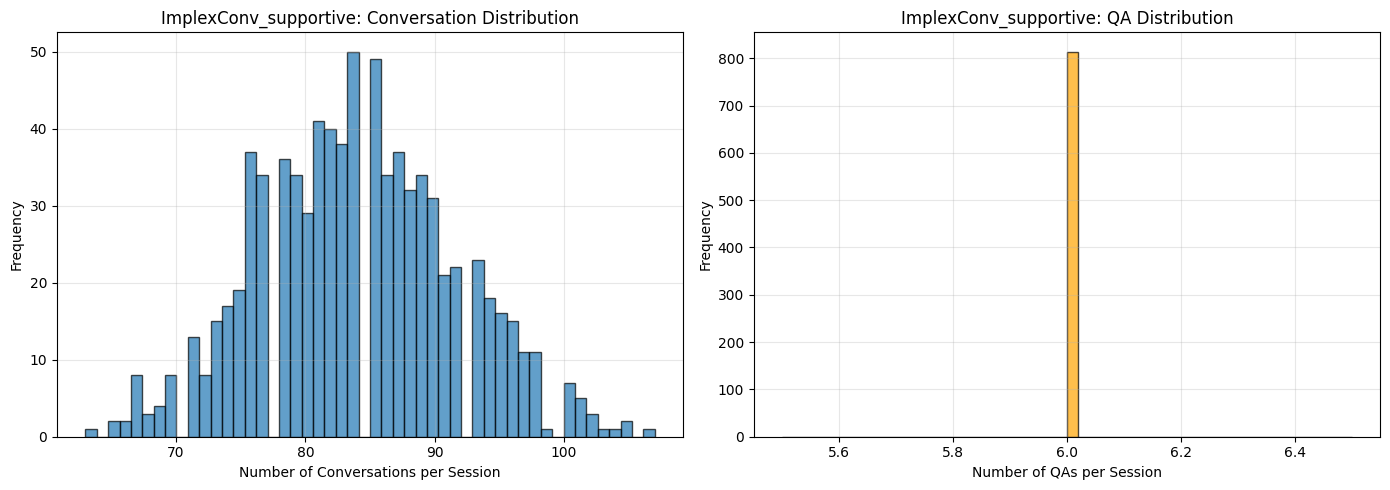

In [2]:
def analyze_dataset(data, name):
    """
    데이터셋 분석: session 개수, conversation 개수, qa 개수
    """
    print(f"\n{'='*50}")
    print(f"Analysis for {name}")
    print(f"{'='*50}")
    
    # 1. Session 개수
    num_sessions = len(data)
    print(f"\nTotal Sessions: {num_sessions}")
    
    # 2. Conversation 개수 분석
    conv_counts = [len(item['conversation']) for item in data]
    print(f"\nConversation counts per session:")
    print(f"  Mean: {np.mean(conv_counts):.2f}")
    print(f"  Min: {np.min(conv_counts)}")
    print(f"  Max: {np.max(conv_counts)}")
    print(f"  Std: {np.std(conv_counts):.2f}")
    
    # 3. QA 개수 분석
    qa_counts = [len(item['qa']) for item in data]
    print(f"\nQA counts per session:")
    print(f"  Mean: {np.mean(qa_counts):.2f}")
    print(f"  Min: {np.min(qa_counts)}")
    print(f"  Max: {np.max(qa_counts)}")
    print(f"  Std: {np.std(qa_counts):.2f}")
    
    # 4. 시각화
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Conversation 히스토그램
    axes[0].hist(conv_counts, bins=50, edgecolor='black', alpha=0.7)
    axes[0].set_xlabel('Number of Conversations per Session')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title(f'{name}: Conversation Distribution')
    axes[0].grid(alpha=0.3)
    
    # QA 히스토그램
    axes[1].hist(qa_counts, bins=50, edgecolor='black', alpha=0.7, color='orange')
    axes[1].set_xlabel('Number of QAs per Session')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title(f'{name}: QA Distribution')
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return conv_counts, qa_counts

conv_opposed, qa_opposed = analyze_dataset(data_opposed, 'ImplexConv_opposed')
conv_supportive, qa_supportive = analyze_dataset(data_supportive, 'ImplexConv_supportive')

## 셀2: 데이터 정제 (QA 기준 Reranking & 0 QA 삭제)

In [3]:
def preprocess_data(data, name):
    """
    1. QA 개수 기준으로 내림차순 정렬
    2. QA가 0인 session 제거
    """
    print(f"\n{'='*50}")
    print(f"Preprocessing {name}")
    print(f"{'='*50}")
    
    # QA 개수와 함께 인덱스 저장
    data_with_idx = [(i, item, len(item['qa'])) for i, item in enumerate(data)]
    
    # QA 개수 기준으로 내림차순 정렬
    data_sorted = sorted(data_with_idx, key=lambda x: x[2], reverse=True)
    
    # QA가 0인 session 제거
    data_filtered = [item for item in data_sorted if item[2] > 0]
    
    print(f"Original sessions: {len(data)}")
    print(f"Sessions with QA > 0: {len(data_filtered)}")
    print(f"Sessions removed: {len(data) - len(data_filtered)}")
    
    # 원본 데이터만 추출 (정렬 순서 반영)
    preprocessed = [item[1] for item in data_filtered]
    
    qa_counts_after = [len(item['qa']) for item in preprocessed]
    print(f"\nQA counts after filtering:")
    print(f"  Mean: {np.mean(qa_counts_after):.2f}")
    print(f"  Min: {np.min(qa_counts_after)}")
    print(f"  Max: {np.max(qa_counts_after)}")
    
    return preprocessed

data_opposed_preprocessed = preprocess_data(data_opposed, 'ImplexConv_opposed')
data_supportive_preprocessed = preprocess_data(data_supportive, 'ImplexConv_supportive')


Preprocessing ImplexConv_opposed
Original sessions: 1550
Sessions with QA > 0: 1433
Sessions removed: 117

QA counts after filtering:
  Mean: 2.54
  Min: 1
  Max: 5

Preprocessing ImplexConv_supportive
Original sessions: 814
Sessions with QA > 0: 814
Sessions removed: 0

QA counts after filtering:
  Mean: 6.00
  Min: 6
  Max: 6


## 셀3: 데이터 재배열

In [4]:
def parse_conversation(conv_text):
    """
    conversation 텍스트를 파싱하여 (speaker, utterance) 리스트 반환
    - 줄 시작의 Assistant:, Speaker1:, Speaker 1: 만 새 turn으로 인식
    - 그 외 줄은 직전 발화에 이어붙임
    - 첫 marker 이전 preamble은 무시
    """
    import re

    speaker_pattern = re.compile(r'^\s*(Assistant|Speaker\s*1)\s*:\s*', re.IGNORECASE | re.MULTILINE)
    turns = []
    matches = list(speaker_pattern.finditer(conv_text))
    
    for idx, match in enumerate(matches):
        speaker_tag = match.group(1).lower().replace(' ', '')
        speaker = 'assistant' if speaker_tag == 'assistant' else 'user'
        start = match.end()
        end = matches[idx + 1].start() if idx + 1 < len(matches) else len(conv_text)
        utterance = conv_text[start:end].strip()
        
        turns.append({
            'speaker': speaker,
            'utterance': utterance
        })
    
    return turns


def restructure_dataset(data, session_offset=0):
    """
    데이터셋을 지정된 구조로 재배열
    
    구조:
    {
        'metadata': {
            'session_id': int,
            'total_conversations': int,
            'total_turns': int
        },
        'conversations': [
            {
                'session_id': int,
                'conv_id': int,
                'turn_id': int,  # conversation 내의 turn 인덱스
                'global_turn_id': int,  # session 내의 전체 turn 순서
                'speaker': str,
                'utterance': str
            },
            ...
        ],
        'qa': [...]
    }
    """
    restructured = []
    
    for session_id, original_item in enumerate(data, start=session_offset):
        session_data = {
            'metadata': {
                'session_id': session_id,
                'total_conversations': len(original_item['conversation']),
                'total_turns': 0  # 나중에 계산
            },
            'conversations': [],
            'qa': original_item['qa']
        }
        
        global_turn_id = 0
        
        # conversation 재배열
        for conv_id in sorted(original_item['conversation'].keys(), key=int):
            conv_text = original_item['conversation'][conv_id]
            turns = parse_conversation(conv_text)
            
            for turn_id, turn_data in enumerate(turns):
                session_data['conversations'].append({
                    'session_id': session_id,
                    'conv_id': int(conv_id),
                    'turn_id': turn_id,
                    'global_turn_id': global_turn_id,
                    'speaker': turn_data['speaker'],
                    'utterance': turn_data['utterance']
                })
                global_turn_id += 1
        
        session_data['metadata']['total_turns'] = global_turn_id
        restructured.append(session_data)
    
    return restructured


print("Restructuring ImplexConv_opposed...")
data_opposed_restructured = restructure_dataset(data_opposed_preprocessed, session_offset=0)
print(f"Restructured {len(data_opposed_restructured)} sessions")

print("\nRestructuring ImplexConv_supportive...")
data_supportive_restructured = restructure_dataset(data_supportive_preprocessed, session_offset=0)
print(f"Restructured {len(data_supportive_restructured)} sessions")

# 샘플 확인
print("\n" + "="*50)
print("Sample structure (ImplexConv_opposed, session 0):")
print("="*50)
print(json.dumps(data_opposed_restructured[0], indent=2)[:1500])

Restructuring ImplexConv_opposed...
Restructured 1433 sessions

Restructuring ImplexConv_supportive...
Restructured 814 sessions

Sample structure (ImplexConv_opposed, session 0):
{
  "metadata": {
    "session_id": 0,
    "total_conversations": 110,
    "total_turns": 1297
  },
  "conversations": [
    {
      "session_id": 0,
      "conv_id": 0,
      "turn_id": 0,
      "global_turn_id": 0,
      "speaker": "user",
      "utterance": "Hi, I'm looking for some advice on educational resources for my kids. Do you have any suggestions?"
    },
    {
      "session_id": 0,
      "conv_id": 0,
      "turn_id": 1,
      "global_turn_id": 1,
      "speaker": "assistant",
      "utterance": "Of course! There are many great educational resources available. Can you tell me a bit more about what you're looking for? What age are your kids, and what subjects are they interested in?"
    },
    {
      "session_id": 0,
      "conv_id": 0,
      "turn_id": 2,
      "global_turn_id": 2,
      "speak

## 셀4: 재처리된 데이터 저장

In [5]:
def save_processed_data(data, output_path):
    """
    재구조화된 데이터를 JSON으로 저장
    """
    with open(output_path, 'w') as f:
        json.dump(data, f, indent=2)
    
    print(f"Saved to {output_path}")
    print(f"  - Sessions: {len(data)}")
    print(f"  - Total conversations: {sum(item['metadata']['total_conversations'] for item in data)}")
    print(f"  - Total turns: {sum(item['metadata']['total_turns'] for item in data)}")
    print(f"  - Total QA pairs: {sum(len(item['qa']) for item in data)}")


output_opposed = os.path.join(data_dir, 'ImplexConv_opposed_processed.json')
output_supportive = os.path.join(data_dir, 'ImplexConv_supportive_processed.json')

print("Saving ImplexConv_opposed_processed.json...")
save_processed_data(data_opposed_restructured, output_opposed)

print("\nSaving ImplexConv_supportive_processed.json...")
save_processed_data(data_supportive_restructured, output_supportive)

print("\n" + "="*50)
print("Preprocessing completed!")
print("="*50)

Saving ImplexConv_opposed_processed.json...
Saved to implexconv/ImplexConv_opposed_processed.json
  - Sessions: 1433
  - Total conversations: 158281
  - Total turns: 1855412
  - Total QA pairs: 3633

Saving ImplexConv_supportive_processed.json...
Saved to implexconv/ImplexConv_supportive_processed.json
  - Sessions: 814
  - Total conversations: 68322
  - Total turns: 733451
  - Total QA pairs: 4884

Preprocessing completed!
